In [1]:
%load_ext kedro.ipython

from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

[01/11/25 18:43:50] INFO     Using                                                                  ]8;id=846413;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=346809;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\framework\project\__init__.py#270\270]8;;\
                             'c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\framewor                
                             k\project\rich_logging.yml' as logging configuration.                                 

[01/11/25 18:43:51] INFO     Registered line magic '%reload_kedro'                                   ]8;id=648938;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=101409;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#61\61]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=80780;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=61510;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#63\63]8;;\

                    INFO     Resolved project path as: d:\UNIWERSYTET WARSZAWSKI\Machine Learning   ]8;id=935601;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=653111;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#178\178]8;;\
                             in Finance\II\Projects\ML_travel_insurance.                                           
                             To set a different path, run '%reload_kedro <project_root>'                           

[01/11/25 18:43:53] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=223352;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=518916;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro_telemetry\plugin.py#233\233]8;;\
                             the product. No personal data or IP addresses are stored on our side. If              
                             you want to opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK`              
                             environment variables, or create a `.telemetry` file in the current                   
                             working directory with the contents `consent: false`. Read more at                    
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

[01/11/25 18:43:54] INFO     Kedro project ML_travel_insurance                                      ]8;id=25561;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=601511;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#144\144]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=713953;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=311498;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#145\145]8;;\
                             'pipelines'                                                                           

In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
)

random_state = catalog.load('params:model_options.random_state')

                    INFO     Loading data from params:model_options.random_state                ]8;id=207326;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=521861;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\
                             (MemoryDataset)...                                                                    

In [3]:
X_train, y_train = catalog.load('TI_train_feature'), catalog.load('TI_y_train_feature')

y_train = pd.DataFrame(y_train).T.iloc[0]

X_test, y_test = catalog.load('TI_test_feature'), catalog.load('TI_y_test_feature')

y_test = pd.DataFrame(y_test).T.iloc[0]

                    INFO     Loading data from TI_train_feature (CSVDataset)...                 ]8;id=181013;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=244274;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_y_train_feature (CSVDataset)...               ]8;id=435992;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=575519;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_test_feature (CSVDataset)...                  ]8;id=107071;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=451242;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_y_test_feature (CSVDataset)...                ]8;id=647130;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=295122;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

### Cross-validation with Undersampling (pre-trained)

In [4]:
logit_trained = catalog.load('logit_trained')
grand_best = logit_trained['grand_best_model']
best_estimators = logit_trained['best_models']

                    INFO     Loading data from logit_trained (PickleDataset)...                 ]8;id=100445;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=241070;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

In [7]:
best_scores = []

for b_est_idx, (best_est_name, best_est) in enumerate(best_estimators):
    y_train_pred = best_est.predict(X_train)
    y_train_proba = best_est.predict_proba(X_train)[:, 1]

    y_test_pred = best_est.predict(X_test)
    y_test_proba = best_est.predict_proba(X_test)[:, 1]

    f1_train = f1_score(y_train, y_train_pred, pos_label=True)
    pr_train = precision_score(y_train, y_train_pred, pos_label=True)
    recall_train = recall_score(y_train, y_train_pred, pos_label=True)
    avg_pr_train = average_precision_score(y_train, y_train_pred, pos_label=True)

    f1_test = f1_score(y_test, y_test_pred, pos_label=True)
    pr_test = precision_score(y_test, y_test_pred, pos_label=True)
    recall_test = recall_score(y_test, y_test_pred, pos_label=True)
    avg_pr_test = average_precision_score(y_test, y_test_pred, pos_label=True)

    best_scores.append([])

    best_scores[b_est_idx] += [
        best_est_name,
        f1_train,
        pr_train,
        recall_train,
        avg_pr_train,
        f1_test,
        pr_test,
        recall_test,
        avg_pr_test,
    ]


best_scores_df = pd.DataFrame(
    best_scores,
    columns=[
        'name',
        'f1_train',
        'precision_train',
        'recall_train',
        'avg_precision_train',
        'f1_test',
        'precision_test',
        'recall_test',
        'avg_precision_test',
    ],
)


best_scores_df

,name,f1_train,precision_train,recall_train,avg_precision_train,f1_test,precision_test,recall_test,avg_precision_test
0,L1,0.088356,0.047225,0.684636,0.036951,0.086505,0.046211,0.675676,0.035961
1,L2,0.087983,0.047018,0.683288,0.036766,0.086326,0.046108,0.675676,0.035891
2,elasticnet,0.087937,0.046992,0.683288,0.036748,0.086356,0.046125,0.675676,0.035903


We got decent somewhat ok-ish recall for positive class, but precision is bad. I think, for this problem of insurance claim, recall is more important (it's important to detect claim situations), although this will lead for claim approval where they shouldn't have been approved.

In [11]:
grand_best[1].get_params()


{
    'Cs': [0.01, 0.25, 0.5, 1.0, 2.0],
    'class_weight': 'balanced',
    'cv': None,
    'dual': False,
    'fit_intercept': True,
    'intercept_scaling': 1.0,
    'l1_ratios': None,
    'max_iter': 10000,
    'multi_class': 'deprecated',
    'n_jobs': 8,
    'penalty': 'l2',
    'random_state': 12345,
    'refit': True,
    'scoring': 'average_precision',
    'solver': 'saga',
    'tol': 0.0001,
    'verbose': 0
}

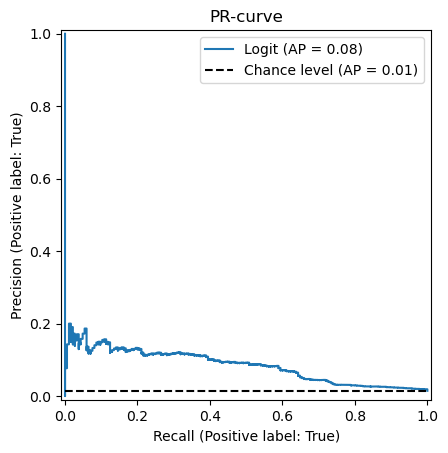

In [13]:
display = PrecisionRecallDisplay.from_estimator(
    grand_best[1], X_test, y_test, name="Logit", plot_chance_level=True
)
_ = display.ax_.set_title("PR-curve")
plt.legend()
plt.show()